# Principal Component Analysis (PCA)

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)


### Creating Sample Dataset

In [47]:
n = 200

# Class 0 (Female)
h0 = np.random.normal(160, 6, n//2) # n//2 is sample size
w0 = np.random.normal(55, 5, n//2)
a0 = np.random.normal(26, 4, n//2)

# Class 1 (Male)
h1 = np.random.normal(175, 7, n//2)
w1 = np.random.normal(72, 6, n//2)
a1 = np.random.normal(30, 5, n//2)

data = pd.DataFrame({
    "Height": np.concatenate([h0, h1]),
    "Weight": np.concatenate([w0, w1]),
    "Age": np.concatenate([a0, a1]),
    "Gender": np.array([0]*(n//2) + [1]*(n//2))
})

df = data.sample(frac=1, random_state=42).reset_index(drop=True)
print(df.head(10))

X = df.drop('Gender', axis=1)
y = df['Gender']


       Height     Weight        Age  Gender
0  153.725736  51.099416  21.115814       0
1  164.509233  52.000611  32.819177       0
2  157.652730  45.126032  23.508225       0
3  177.348538  71.227274  28.426789       1
4  175.959058  62.002305  24.188499       1
5  173.687850  73.830682  31.002413       1
6  150.375285  62.145586  24.472772       0
7  171.182354  72.671033  33.068892       1
8  173.978461  70.148451  29.462869       1
9  161.893992  53.933781  25.299002       0


### Standardizing the Data

Since the features have different scales Height vs Age we standardize the data. This makes all features have mean = 0 and standard deviation = 1 so that no feature dominates just because of its units.

### Applying PCA Algorithm

We reduce the data from 3 features to 2 new features called principal components. These components capture most of the original information but in fewer dimensions.


In [78]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)


[0.6304098  0.27236096]


### Visualizing PCA Result

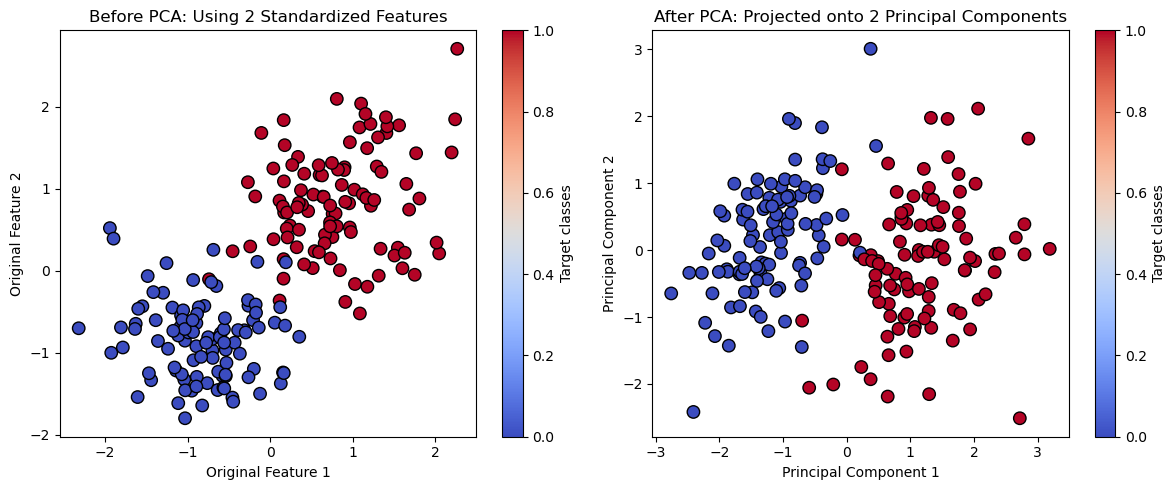

In [79]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()


- Left Plot Before PCA: This shows the original standardized data plotted using the first two features. There is no guarantee of clear separation between classes as these are raw input dimensions.
- Right Plot After PCA: This displays the transformed data using the top 2 principal components. These new components capture the maximum variance often showing better class separation and structure making it easier to analyze or model.


### Logistic Regression
- We split the data into 70% training and 30% testing sets.
- We train a logistic regression model on the reduced training data and predict gender labels on the test set.

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)


### Evaluating with Confusion Matrix

The confusion matrix compares actual vs predicted labels. This makes it easy to see where predictions were correct or wrong.

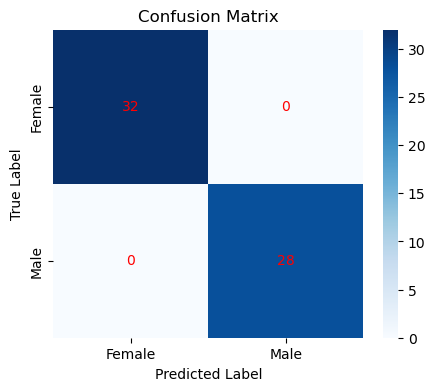

In [82]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
# print(cm)

plt.figure(figsize=(5,4))
ax = sns.heatmap(cm, cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])

# manual annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha='center', va='center', color='red')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**The point is to pack up highly correlated features in preprocessing stage.**